In [1]:
import pandas as pd 
import plotly.express as px


In [2]:
 df = pd.read_csv('petrol_price.csv')
 df.info()
 df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            67 non-null     object 
 1   Maharashtra     67 non-null     float64
 2    Haryana        67 non-null     float64
 3   Delhi           67 non-null     float64
 4   Gujarat         67 non-null     float64
 5   Karnataka       67 non-null     float64
 6   Telangana       67 non-null     float64
 7   Rajasthan       67 non-null     float64
 8   Punjab          67 non-null     float64
 9   West_bengal     67 non-null     float64
 10  Tamil Nadu      67 non-null     float64
 11   Uttar Pradesh  67 non-null     float64
 12  Madhya Pradesh  67 non-null     float64
 13  Kerala          67 non-null     float64
 14  Assam           67 non-null     float64
 15  Bihar           67 non-null     float64
dtypes: float64(15), object(1)
memory usage: 8.5+ KB


,Maharashtra,Haryana,Delhi,Gujarat,Karnataka,Telangana,Rajasthan,Punjab,West_bengal,Tamil Nadu,Uttar Pradesh,Madhya Pradesh,Kerala,Assam,Bihar
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,89.094030,80.561343,81.278209,79.951343,84.020597,86.935672,86.625373,83.088955,84.542836,84.281940,81.551045,88.570597,85.668657,82.019254,86.291343
std,13.338161,11.747156,12.036261,11.988457,13.031010,14.264798,15.036667,11.015556,13.359466,12.260133,10.898700,14.080720,13.778086,10.526686,13.352867
min,74.300000,62.680000,63.090000,64.770000,64.240000,67.020000,65.770000,67.930000,66.140000,65.460000,66.530000,69.620000,66.930000,65.830000,65.930000
25%,78.350000,71.390000,71.595000,70.210000,73.745000,76.020000,74.170000,73.510000,74.030000,74.480000,72.150000,77.070000,75.025000,72.530000,75.995000
50%,83.760000,76.520000,76.310000,75.680000,78.770000,80.900000,79.260000,81.490000,79.200000,79.260000,77.110000,83.220000,79.470000,78.510000,82.050000
75%,99.145000,91.025000,92.830000,92.030000,95.930000,98.010000,99.370000,93.540000,93.630000,95.115000,90.705000,100.910000,96.495000,89.600000,95.340000
max,120.510000,106.620000,109.690000,106.530000,113.560000,119.490000,118.030000,110.610000,115.120000,110.850000,106.610000,118.460000,117.190000,105.740000,116.230000


In [3]:

df.sample(15)

,date,Maharashtra,Haryana,Delhi,Gujarat,Karnataka,Telangana,Rajasthan,Punjab,West_bengal,Tamil Nadu,Uttar Pradesh,Madhya Pradesh,Kerala,Assam,Bihar
66,2022_Sep,106.31,97.43,96.72,96.63,101.94,109.66,108.48,96.18,106.03,102.63,96.57,108.65,107.71,96.01,107.24
17,2018_Nov,84.86,77.70,79.39,76.63,79.99,84.14,79.97,84.62,81.25,82.46,77.15,82.52,82.65,79.16,83.06
27,2019_Mar,77.44,71.74,71.81,69.42,74.20,76.20,72.58,71.73,73.90,74.57,71.27,74.90,75.11,71.35,75.86
1,2017_Dec,76.52,68.78,69.22,68.06,70.29,73.29,71.83,74.21,71.98,71.74,71.58,73.93,72.99,71.13,73.57
35,2020_Feb,78.83,72.64,73.19,70.78,75.66,77.85,77.04,73.11,75.85,76.03,74.72,81.34,76.56,75.33,77.87
31,2019_Sep,77.46,71.55,71.77,69.44,74.22,76.30,75.75,71.66,74.50,74.57,73.63,76.96,75.14,73.88,75.44
3,2017_Jun,78.44,66.70,66.91,68.91,71.59,71.49,69.88,72.51,69.52,69.93,69.86,74.65,71.27,70.52,69.85
6,2017_Oct,79.87,70.31,70.76,72.58,71.87,74.93,73.41,75.80,73.50,73.36,72.79,77.18,74.62,72.73,75.09
4,2017_May,77.46,67.84,68.09,71.15,73.01,72.68,71.12,73.41,70.68,71.17,70.74,75.87,72.43,71.41,71.16
26,2019_Jun,77.28,71.41,71.62,69.25,74.01,76.05,72.39,71.48,73.74,74.39,71.13,74.73,74.88,71.17,75.73


In [4]:
average_prices = df.drop('date', axis=1).mean(axis=0).reset_index()
average_prices.columns = ['State', 'Average Petrol Price']

fig = px.bar(
    average_prices,
    x='State',
    y='Average Petrol Price',
    title='Average Petrol Price Over the Last 4 Years',
    labels={'Average Petrol Price': 'Average Petrol Price (INR)'}
)

fig.show()


In [5]:
df_maharashtra_delhi = df[['date', 'Maharashtra', 'Delhi']]
df_maharashtra_delhi = pd.melt(df_maharashtra_delhi, id_vars='date', var_name='State', value_name='Petrol Price')

fig = px.line(
    df_maharashtra_delhi,
    x='date',
    y='Petrol Price',
    color='State',
    title='Petrol Prices Comparison Between Maharashtra and Delhi',
    labels={'Petrol Price': 'Petrol Price (INR)', 'date': 'Month'}
)
fig.show()


In [6]:
 fig1 = px.line(df, x='date', y=df.columns[1:], title='Petrol Prices Trend Over 5 Years')
 fig1.show()
 

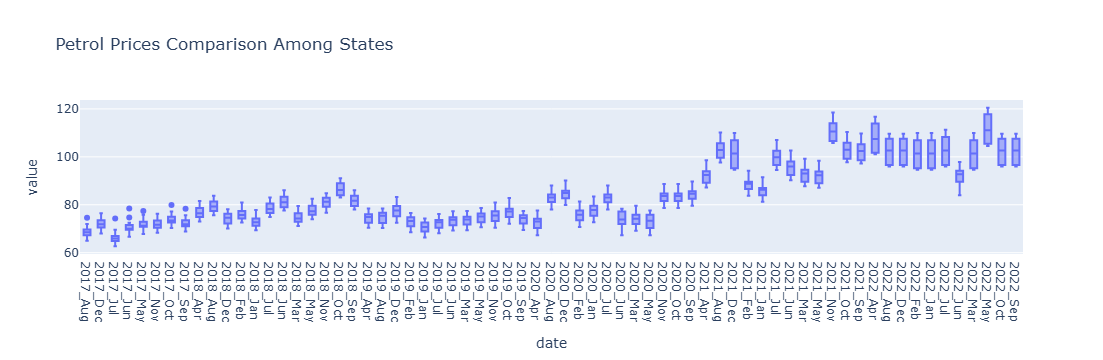

In [7]:
fig2 = px.box(df, x='date', y=df.columns[1:], title='Petrol Prices Comparison Among States')
fig2.show()

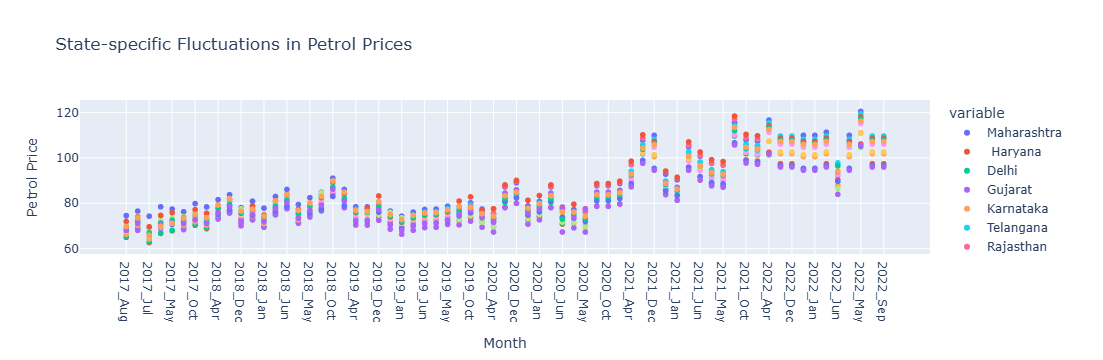

In [13]:
fig5 = px.scatter(df, x='date', y=df.columns[1:], title='State-specific Fluctuations in Petrol Prices',
                  labels={'value': 'Petrol Price', 'date': 'Month'})
fig5.show()

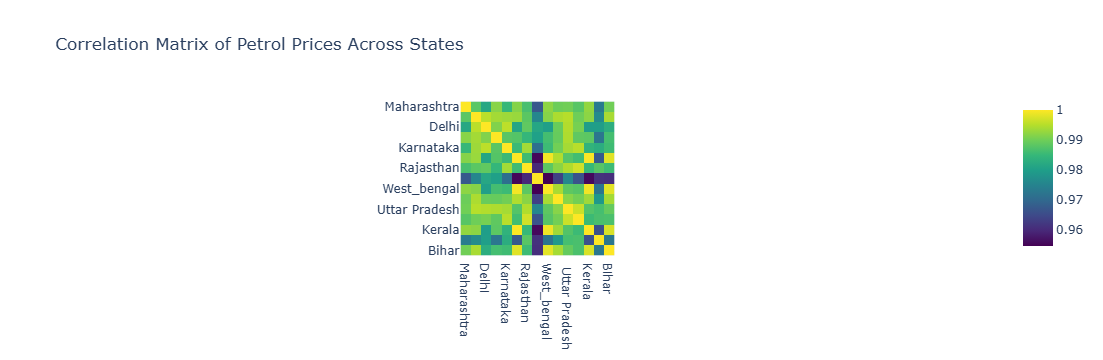

In [9]:
numeric_columns = df.drop('date', axis=1)
correlation_matrix = numeric_columns.corr()

fig4 = px.imshow(
    correlation_matrix,
    x=numeric_columns.columns,
    y=numeric_columns.columns,
    color_continuous_scale='Viridis',
    title='Correlation Matrix of Petrol Prices Across States'
)
fig4.show()


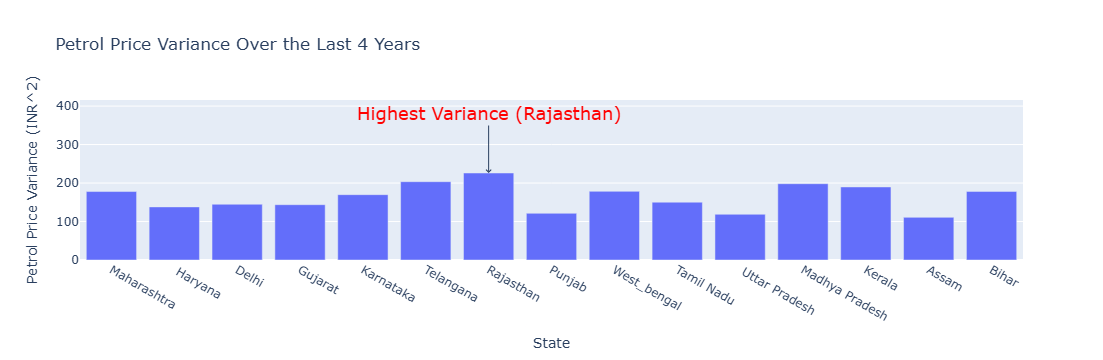

In [31]:
variance_prices = df.drop('date', axis=1).var(axis=0).reset_index()
variance_prices.columns = ['State', 'Petrol Price Variance']


highest_var_state = variance_prices.loc[variance_prices['Petrol Price Variance'].idxmax(), 'State']
fig = px.bar(variance_prices, x='State', y='Petrol Price Variance',
             title='Petrol Price Variance Over the Last 4 Years',
             labels={'Petrol Price Variance': 'Petrol Price Variance (INR^2)'})
fig.update_layout(annotations=[dict(x=highest_var_state, y=variance_prices['Petrol Price Variance'].max(),
                                    text=f'Highest Variance ({highest_var_state})', showarrow=True, arrowhead=4,
                                    ax=0, ay=-60, font=dict(size=18, color='red')),
                               ],
                  showlegend=False) 
fig.show() 

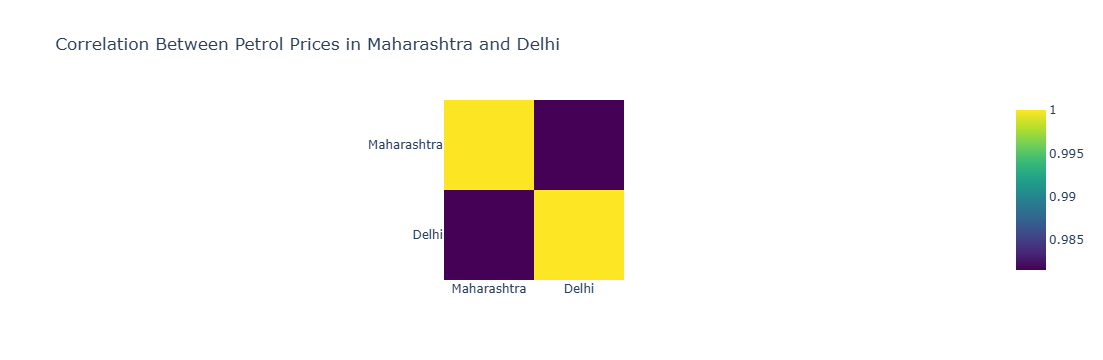

In [29]:
correlation_data = df[['Maharashtra', 'Delhi']]
correlation_matrix = correlation_data.corr()
fig = px.imshow(correlation_matrix, x=correlation_data.columns, y=correlation_data.columns,
 color_continuous_scale='Viridis', title='Correlation Between Petrol Prices in Maharashtra and Delhi')
fig.show()
